In [7]:
import jax
print(jax.default_backend())
print(jax.devices())


gpu
[CudaDevice(id=0)]


In [8]:
# add project root (parent of figures) to module search path
import sys, os
sys.path.insert(0, os.path.abspath('/home/reilly/Documents/code/EDGAR-main/'))
# import packages
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
import statsmodels.api as sm
from tqdm import tqdm
# import local modules
import utils, loss_functions, seed_programs

# Model Definitions 
## (Uncomment the model you want)

In [ ]:
# # BASELINE MODEL
neuron_model_gauss = seed_programs.neuron_model_2_jax
parameter_estimator_gauss = seed_programs.parameter_estimator_2

# AI MODEL
def neuron_model(theta,
                theta_pref_1=0.0,
                baseline=0.0,
                amplitude_1=1.0,
                width_ccw_1=1.0,
                width_cw_1=1.0,
                exponent_1=2.0,
                theta_pref_2=jnp.pi,
                amplitude_2=0.0,
                width_ccw_2=1.0,
                width_cw_2=1.0,
                exponent_2=2.0):

    min_width = 1e-1
    eps = 1e-12
    min_exponent, max_exponent = 0.1, 5.0
    width_ccw_1, width_cw_1 = jnp.clip(width_ccw_1, min_width, None), jnp.clip(width_cw_1, min_width, None)
    width_ccw_2, width_cw_2 = jnp.clip(width_ccw_2, min_width, None), jnp.clip(width_cw_2, min_width, None)
    exponent_1, exponent_2 = jnp.clip(exponent_1, min_exponent, max_exponent), jnp.clip(exponent_2, min_exponent, max_exponent)
    baseline = jnp.clip(baseline, 0.0, None)
    amplitude_1, amplitude_2 = jnp.clip(amplitude_1, 0.0, None), jnp.clip(amplitude_2, 0.0, None)

    def _signed_circ_diff_rad(angle_radians, preferred_angle_radians):
        delta = angle_radians - preferred_angle_radians
        return jnp.arctan2(jnp.sin(delta), jnp.cos(delta))
        
    signed_diff_1 = _signed_circ_diff_rad(theta, theta_pref_1) + eps  # Add small epsilon to avoid log(0) issues
    width_1_effective = jnp.where(signed_diff_1 < 0, width_ccw_1, width_cw_1)
    width_1_effective = jnp.maximum(width_1_effective, 1e-6)
    peak1_component = amplitude_1 * jnp.exp(-0.5 * (jnp.abs(signed_diff_1) / width_1_effective) ** exponent_1)

    signed_diff_2 = _signed_circ_diff_rad(theta, theta_pref_2) + eps  # Add small epsilon to avoid log(0) issues
    width_2_effective = jnp.where(signed_diff_2 < 0, width_ccw_2, width_cw_2)
    width_2_effective = jnp.maximum(width_2_effective, 1e-6)
    peak2_component = amplitude_2 * jnp.exp(-0.5 * (jnp.abs(signed_diff_2) / width_2_effective) ** exponent_2)
    return baseline + peak1_component + peak2_component

def parameter_estimator(stimuli, spike_counts):
    """
    Estimates parameters for the neuron_model_v3 based on stimulus angles and observed spike counts.
    This estimator employs statistical principles to identify and characterize tuning curve peaks,
    including baseline, amplitude, asymmetric widths, preferred directions, and exponents for
    two potential peaks.

    Parameters are estimated directly from a smoothed firing rate curve, aiming for a simple
    yet robust initial estimation suitable for generalized Gaussian-like tuning profiles.

    Parameters:
    stimuli (np.ndarray): An array of stimulus angles in radians (0 to 2*pi).
    spike_counts (np.ndarray): An array of spike counts corresponding to each stimulus.

    Returns:
    np.ndarray: An array containing the estimated parameters in the following order:
                [theta_pref_1, baseline, amplitude_1, width_ccw_1, width_cw_1,
                 exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2]
    """
    # --- Configuration Constants ---
    n_bins = 256  # Number of angular bins for tuning curve estimation
    kernel_sigma = 2.5 # Sigma for Gaussian smoothing kernel
    min_peak_amplitude = 0.5 # Min amplitude (spikes/stimulus) above baseline for a peak to be considered valid
    min_model_width = 1e-6 # Minimum allowed width for numerical stability (as per model)
    default_width_value = 1.0 # Default width for non-significant peaks or non-determinable widths
    min_exponent = 0.1 # Minimum allowed exponent value
    max_exponent = 5.0 # Maximum allowed exponent value
    default_exponent_value = 2.0 # Default exponent (Gaussian)
    min_second_peak_ratio = 0.1 # Min amplitude of secondary peak relative to primary
    min_second_peak_separation = np.pi / 4 # Min angular separation between primary and secondary peaks

    # --- 1. Binning and Smoothing ---
    # Convert stimuli to bin indices, handle wrap-around implicitly by modulo in bincount
    bin_idx = ((stimuli * n_bins) / (2 * np.pi)).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)

    # Create Gaussian smoothing kernel
    kernel_radius = int(3 * kernel_sigma)
    x_kernel = np.arange(-kernel_radius, kernel_radius + 1)
    kernel = np.exp(-0.5 * (x_kernel / kernel_sigma) ** 2)
    kernel /= (np.sum(kernel) + 1e-8) # Normalize kernel

    # Pad arrays for circular convolution
    pad = len(kernel) // 2
    sums_padded = np.pad(sums, (pad, pad), mode='wrap')
    counts_padded = np.pad(counts, (pad, pad), mode='wrap')

    # Convolve to get smoothed sum of spikes and counts
    num_conv = np.convolve(sums_padded, kernel, mode='valid')
    den_conv = np.convolve(counts_padded, kernel, mode='valid')

    # Calculate smoothed tuning curve (avoid division by zero)
    tuning_curve = np.zeros_like(num_conv, dtype=float)
    valid_den_mask = den_conv > 1e-8
    tuning_curve[valid_den_mask] = num_conv[valid_den_mask] / den_conv[valid_den_mask]

    angle_step = 2 * np.pi / n_bins

    # --- 2. Baseline Estimation ---
    # Baseline cannot be negative
    baseline_est = np.maximum(0.0, np.min(tuning_curve))

    # --- Helper function for estimating peak shape parameters ---
    def _get_peak_params_simple(peak_idx_val, peak_idx, bsl, tc, n_bns, ang_step,
                                min_w, def_w, min_exp, max_exp, def_exp, min_amp_thresh):
        amp = peak_idx_val - bsl
        if amp < min_amp_thresh:
            return amp, def_w, def_w, def_exp # Return default parameters if amplitude too small

        # Find bins where tuning curve drops below half-max
        target_half_val = bsl + amp / 2.0
        half_ccw_bins, half_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if half_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_half_val:
                half_ccw_bins = k
            if half_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_half_val:
                half_cw_bins = k
            if half_ccw_bins > 0 and half_cw_bins > 0:
                break
        
        # Calculate width (v1-style, implicitly assuming Gaussian form for width parameter base)
        SQRT_2_LOG_2 = np.sqrt(2 * np.log(2)) 
        width_ccw = (half_ccw_bins * ang_step) / SQRT_2_LOG_2 if half_ccw_bins > 0 else def_w
        width_cw = (half_cw_bins * ang_step) / SQRT_2_LOG_2 if half_cw_bins > 0 else def_w
        
        # Clip widths to valid range
        width_ccw = np.clip(width_ccw, min_w, np.pi)
        width_cw = np.clip(width_cw, min_w, np.pi)

        # Find bins where tuning curve drops below quarter-max for exponent estimation
        target_qtr_val = bsl + amp / 4.0
        qtr_ccw_bins, qtr_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if qtr_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_qtr_val:
                qtr_ccw_bins = k
            if qtr_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_qtr_val:
                qtr_cw_bins = k
            if qtr_ccw_bins > 0 and qtr_cw_bins > 0:
                break
        
        # Exponent estimation (log(2) / log(dist_qtr / dist_half))
        exponent_estimates = []
        if half_ccw_bins > 0 and qtr_ccw_bins > half_ccw_bins: # Ensure ratio > 1 for valid log
            exponent_estimates.append(np.log(2) / np.log(qtr_ccw_bins / half_ccw_bins))
        if half_cw_bins > 0 and qtr_cw_bins > half_cw_bins:
            exponent_estimates.append(np.log(2) / np.log(qtr_cw_bins / half_cw_bins))
        
        # Take mean of valid estimates, else default
        exponent = np.mean(exponent_estimates) if exponent_estimates else def_exp
        exponent = np.clip(exponent, min_exp, max_exp)
        
        return amp, width_ccw, width_cw, exponent

    # --- 3. Peak Identification and Parameter Estimation ---
    # Find all local maxima in the smoothed tuning curve
    local_maxima = []
    for i in range(n_bins):
        prev_val = tuning_curve[(i - 1 + n_bins) % n_bins]
        next_val = tuning_curve[(i + 1) % n_bins]
        if tuning_curve[i] >= prev_val and tuning_curve[i] >= next_val:
            local_maxima.append((tuning_curve[i], i))
    local_maxima.sort(key=lambda x: x[0], reverse=True) # Sort by peak amplitude (descending)

    # Initialize all output parameters with model defaults (if no peak is found)
    theta_pref_1 = 0.0
    amplitude_1 = default_width_value # amplitude for primary peak default to 1 for non-zero contribution if peak is small
    width_ccw_1, width_cw_1, exponent_1 = default_width_value, default_width_value, default_exponent_value
    
    theta_pref_2 = np.pi # Antipodal to default theta_pref_1
    amplitude_2 = 0.0 # Default no second peak
    width_ccw_2, width_cw_2, exponent_2 = default_width_value, default_width_value, default_exponent_value

    # Process Primary Peak
    if local_maxima:
        peak_1_val, peak_1_idx = local_maxima[0]
        # Estimate parameters for the primary (highest) peak
        amplitude_1, width_ccw_1, width_cw_1, exponent_1 = \
            _get_peak_params_simple(peak_1_val, peak_1_idx, baseline_est, tuning_curve, n_bins, angle_step,
                                    min_model_width, default_width_value, min_exponent, max_exponent,
                                    default_exponent_value, min_peak_amplitude)
        theta_pref_1 = peak_1_idx * angle_step
        
        # Process Secondary Peak (if a suitable candidate exists)
        if len(local_maxima) > 1:
            # Iterate through other local maxima to find a suitable secondary peak
            for i in range(1, len(local_maxima)):
                peak_2_val_candidate, peak_2_idx_candidate = local_maxima[i]
                current_amplitude_2_candidate = peak_2_val_candidate - baseline_est
                current_theta_pref_2_candidate = peak_2_idx_candidate * angle_step
                
                # Check amplitude significance relative to primary peak's estimated amplitude
                if current_amplitude_2_candidate < (amplitude_1 * min_second_peak_ratio):
                    continue # Skip if too small compared to the primary peak
                
                # Check angular separation from the *primary* peak
                # np.arctan2(sin(a-b), cos(a-b)) gives circular distance in [-pi, pi]
                peak_sep_rad = np.abs(np.arctan2(np.sin(theta_pref_1 - current_theta_pref_2_candidate),
                                                 np.cos(theta_pref_1 - current_theta_pref_2_candidate)))
                if peak_sep_rad < min_second_peak_separation:
                    continue # Skip if too close to the primary peak

                # Valid secondary peak found, estimate its parameters
                amplitude_2, width_ccw_2, width_cw_2, exponent_2 = \
                    _get_peak_params_simple(peak_2_val_candidate, peak_2_idx_candidate, baseline_est, tuning_curve, n_bins, angle_step,
                                            min_model_width, default_width_value, min_exponent, max_exponent,
                                            default_exponent_value, min_peak_amplitude)
                theta_pref_2 = current_theta_pref_2_candidate
                
                # Break after finding the first suitable secondary peak (highest amplitude among remaining candidates)
                break
    
    # --- Pack and return parameters in the correct order for neuron_model_v3 ---
    return np.array([theta_pref_1, baseline_est, amplitude_1, width_ccw_1, width_cw_1,
                     exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2])
 
param_names = ['theta_pref_1', 'baseline', 'amplitude_1', 'width_ccw_1', 'width_cw_1',
               'exponent_1', 'theta_pref_2', 'amplitude_2', 'width_ccw_2', 'width_cw_2',
               'exponent_2']

neuron_model_vmap = utils.vmap_over_cells(neuron_model)
neuron_model_gauss_vmap = utils.vmap_over_cells(neuron_model_gauss)

# SINGLE-PEAK MODEL
# neuron_model_gauss_single_peak = seed_programs.neuron_model_1_jax
# parameter_estimator_gauss_single_peak = seed_programs.parameter_estimator_1

# # AI MODEL - SINGLE PEAK
# def neuron_model_single(theta,
#                         theta_pref=0.0,
#                         baseline=0.0,
#                         amplitude=1.0,
#                         width_ccw=1.0,
#                         width_cw=1.0,
#                         exponent=2.0):
#     """
#     Single-peak circularly tuned neuron model with asymmetric widths and generalized Gaussian exponent.
#     """
#     min_width = 5e-2
#     eps = 1e-12
#     min_exponent, max_exponent = 0.1, 5.0

#     # Parameter clipping
#     width_ccw, width_cw = jnp.clip(width_ccw, min_width, None), jnp.clip(width_cw, min_width, None)
#     exponent = jnp.clip(exponent, min_exponent, max_exponent)
#     baseline = jnp.clip(baseline, 0.0, None)
#     amplitude = jnp.clip(amplitude, 0.0, None)

#     # Circular signed difference
#     def _signed_circ_diff_rad(angle_radians, preferred_angle_radians):
#         delta = angle_radians - preferred_angle_radians
#         return jnp.arctan2(jnp.sin(delta), jnp.cos(delta))

#     signed_diff = _signed_circ_diff_rad(theta, theta_pref) + eps
#     width_effective = jnp.where(signed_diff < 0, width_ccw, width_cw)
#     width_effective = jnp.maximum(width_effective, 1e-6)

#     # Generalized Gaussian shape
#     peak_component = amplitude * jnp.exp(-0.5 * (jnp.abs(signed_diff) / width_effective) ** exponent)
#     return baseline + peak_component

# def parameter_estimator_single(stimuli, spike_counts):
#     """
#     Estimate parameters for the single-peak neuron model.

#     Parameters:
#         stimuli (np.ndarray): Angles (radians, 0 to 2π)
#         spike_counts (np.ndarray): Spike counts

#     Returns:
#         np.ndarray: [theta_pref, baseline, amplitude, width_ccw, width_cw, exponent]
#     """
#     n_bins = 256
#     kernel_sigma = 2.5
#     min_model_width = 1e-6
#     default_width = 1.0
#     min_exponent, max_exponent = 0.1, 5.0
#     default_exponent = 2.0
#     min_peak_amplitude = 0.5

#     # --- Binning ---
#     bin_idx = ((stimuli * n_bins) / (2 * np.pi)).astype(np.int32)
#     bin_idx = np.clip(bin_idx, 0, n_bins - 1)

#     sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
#     counts = np.bincount(bin_idx, minlength=n_bins)

#     # --- Smoothing (circular Gaussian) ---
#     kernel_radius = int(3 * kernel_sigma)
#     x = np.arange(-kernel_radius, kernel_radius + 1)
#     kernel = np.exp(-0.5 * (x / kernel_sigma) ** 2)
#     kernel /= np.sum(kernel) + 1e-8

#     pad = len(kernel) // 2
#     sums_padded = np.pad(sums, (pad, pad), mode='wrap')
#     counts_padded = np.pad(counts, (pad, pad), mode='wrap')

#     num_conv = np.convolve(sums_padded, kernel, mode='valid')
#     den_conv = np.convolve(counts_padded, kernel, mode='valid')

#     tuning_curve = np.zeros_like(num_conv)
#     valid_mask = den_conv > 1e-8
#     tuning_curve[valid_mask] = num_conv[valid_mask] / den_conv[valid_mask]

#     angle_step = 2 * np.pi / n_bins

#     # --- Baseline ---
#     baseline = np.maximum(0.0, np.min(tuning_curve))

#     # --- Peak detection ---
#     peak_idx = np.argmax(tuning_curve)
#     peak_val = tuning_curve[peak_idx]
#     amplitude = peak_val - baseline

#     if amplitude < min_peak_amplitude:
#         return np.array([0.0, baseline, amplitude, default_width, default_width, default_exponent])

#     # --- Estimate width & exponent ---
#     target_half_val = baseline + amplitude / 2
#     half_ccw_bins, half_cw_bins = 0, 0
#     for k in range(1, n_bins // 2 + 1):
#         if half_ccw_bins == 0 and tuning_curve[(peak_idx - k) % n_bins] <= target_half_val:
#             half_ccw_bins = k
#         if half_cw_bins == 0 and tuning_curve[(peak_idx + k) % n_bins] <= target_half_val:
#             half_cw_bins = k
#         if half_ccw_bins > 0 and half_cw_bins > 0:
#             break

#     SQRT_2_LOG_2 = np.sqrt(2 * np.log(2))
#     width_ccw = (half_ccw_bins * angle_step) / SQRT_2_LOG_2 if half_ccw_bins > 0 else default_width
#     width_cw = (half_cw_bins * angle_step) / SQRT_2_LOG_2 if half_cw_bins > 0 else default_width
#     width_ccw = np.clip(width_ccw, min_model_width, np.pi)
#     width_cw = np.clip(width_cw, min_model_width, np.pi)

#     # Exponent from half vs quarter
#     target_qtr_val = baseline + amplitude / 4
#     qtr_ccw_bins, qtr_cw_bins = 0, 0
#     for k in range(1, n_bins // 2 + 1):
#         if qtr_ccw_bins == 0 and tuning_curve[(peak_idx - k) % n_bins] <= target_qtr_val:
#             qtr_ccw_bins = k
#         if qtr_cw_bins == 0 and tuning_curve[(peak_idx + k) % n_bins] <= target_qtr_val:
#             qtr_cw_bins = k
#         if qtr_ccw_bins > 0 and qtr_cw_bins > 0:
#             break

#     exponent_est = []
#     if half_ccw_bins > 0 and qtr_ccw_bins > half_ccw_bins:
#         exponent_est.append(np.log(2) / np.log(qtr_ccw_bins / half_ccw_bins))
#     if half_cw_bins > 0 and qtr_cw_bins > half_cw_bins:
#         exponent_est.append(np.log(2) / np.log(qtr_cw_bins / half_cw_bins))
#     exponent = np.mean(exponent_est) if exponent_est else default_exponent
#     exponent = np.clip(exponent, min_exponent, max_exponent)

#     theta_pref = peak_idx * angle_step

#     return np.array([theta_pref, baseline, amplitude, width_ccw, width_cw, exponent])


# Data Loading and Visualization

In [11]:
# 1. Jacob Blocked Data (n_bins=256, signal_fraction_thresh=0.85)
# data_dirs = ['/home/reilly/Desktop/jacob data/bz15/data2.npy', '/home/reilly/Desktop/jacob data/bz15/data3.npy', '/home/reilly/Desktop/jacob data/bz15/data5.npy']
# metadata_dirs = ['/home/reilly/Desktop/jacob data/bz15/meta2.mat', '/home/reilly/Desktop/jacob data/bz15/meta3.mat', '/home/reilly/Desktop/jacob data/bz15/meta5.mat']

# 2. Jacob Continuous Data (n_bins=180, signal_fraction_thresh=0.85)
# data_dirs = ['/home/reilly/Desktop/BZ016_2025-06-24_1_dspikes.npy']
# metadata_dirs = ['/home/reilly/Desktop/2025-06-24_1_BZ016_Block.mat']

# 3. Ali Lightbeads Data (n_bins = 90)
# data_dir = '/home/reilly/Downloads/grating-data-M01-D1.pickle'

# for all stringer data: n_bins=256, signal_fraction_thresh=0.9
# 4. Stringer Data 1
# data_dir = '/home/reilly/Downloads/8279387/gratings_drifting_GT1_2019_04_12_1.npy'

# 5. Stringer Data 2
# data_dir = '/home/reilly/Downloads/8279387/gratings_drifting_GT2_2019_04_05_1.npy'

# 6. Stringer Data 3
# data_dir = '/home/reilly/datasets/stringer_2021/gratings_drifting_GT3_2019_04_05_1.npy'
# response, angles = utils.load_data(data_dir = data_dir,
#                                    data_type='stringer',
#                                    conc_thresh=0.4,
#                                    activity_thresh=0.0,
#                                    signal_fraction_thresh=0.85,
#                                    n_bins=256, min_repeats=6)
# signal_fractions = utils.unbiased_signal_fraction(response)[0]

# # 7. Hayley data
data_dir = '/home/reilly/datasets/hayley_data/spike_counts.npy'
response, angles, global_cell_indices = utils.load_data(data_dir = data_dir,
                                   data_type='hayley',
                                   conc_thresh=0.0,
                                   activity_thresh=0.0,
                                   signal_fraction_thresh=0.55,
                                   n_bins=360, min_repeats=6, return_indices=True)
signal_fractions = utils.unbiased_signal_fraction(response)[0]
 

Selected 564 / 564 cells with activity > 0.0 and concentration > 0.0.
Selected 257 / 564 cells with signal fraction > 0.55.


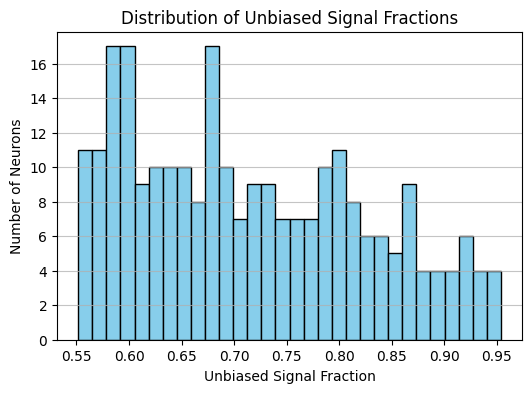

In [12]:
# plot histogram of signal fractions
plt.figure(figsize=(6,4))
plt.hist(signal_fractions, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Unbiased Signal Fraction')
plt.ylabel('Number of Neurons')
plt.title('Distribution of Unbiased Signal Fractions')
plt.grid(axis='y', alpha=0.75)
plt.show()

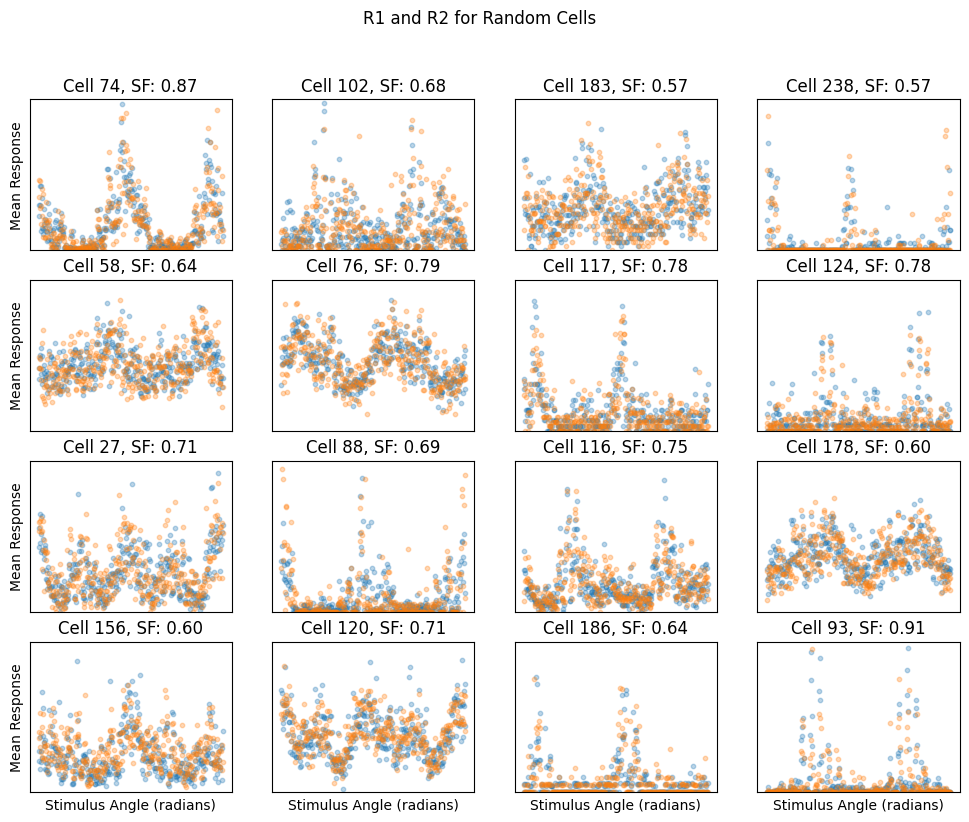

In [13]:
# choose 16 random cells to plot fits for
n_cells = response.shape[1]
random_cells = np.random.choice(n_cells, size=16, replace=False)
plt.figure(figsize=(12, 9))
for i, cell_no in enumerate(random_cells):
    plt.subplot(4, 4, i + 1)
    # plt.scatter(angles, response[:, cell_no].mean(axis=0), s=10, alpha=0.5, label='Data')
    plt.scatter(angles, np.nanmean(response[::2, cell_no], axis=0), s=10, alpha=0.3, label='train')
    plt.scatter(angles, np.nanmean(response[1::2, cell_no], axis=0), s=10, alpha=0.3, label='test')
    row, col = i // 4, i % 4
    if row == 3:
        plt.xlabel('Stimulus Angle (radians)')
    if col == 0:
        plt.ylabel('Mean Response')
    plt.title(f'Cell {cell_no}, SF: {signal_fractions[cell_no]:.2f}')
    plt.ylim(0, np.nanpercentile(response[:, cell_no], 99) * 1.1)
    plt.xticks([])
    plt.yticks([])
plt.suptitle('R1 and R2 for Random Cells')
plt.show()

# Parameter Fitting

In [14]:
# neuron_model_vmap = utils.vmap_over_cells(neuron_model)
# neuron_model_gauss_vmap = utils.vmap_over_cells(neuron_model_gauss)
n_repeats, n_cells, n_bins = response.shape

# permute repeats
# response = response[np.random.permutation(n_repeats)]
# n_train_repeats = n_repeats // 2
# n_test_repeats = n_repeats - n_train_repeats
# train_repeats = np.random.choice(n_repeats, size=n_train_repeats, replace=False)
# test_repeats = np.setdiff1d(np.arange(n_repeats), train_repeats)
# define train/test splits
R_train = np.nanmean(response[::2], axis=0)
R_test = np.nanmean(response[1::2], axis=0)
print(R_train.shape, R_test.shape)

# # compute mean responses and double-angle versions
# R_mean = np.nanmean(response[::2], axis=0)
# R_mean_double = (R_mean[:, :n_bins//2] + R_mean[:, n_bins//2:]) / 2.0
# angles_double = angles[::2]
# F_0 = (response[:, :, :n_bins//2] + response[:, :, n_bins//2:]) / 2.0
# F_0_train = np.nanmean(F_0[::2], axis=0)
# F_0_test = np.nanmean(F_0[1::2], axis=0)
# print(angles_double.shape, F_0_train.shape, F_0_test.shape)


(257, 360) (257, 360)
(180,) (257, 180) (257, 180)


In [18]:
# train models with simple per-cell Adam.
# cells whose predictions contain NaN get zero gradient that step (freeze) rather than corrupting params.
import optax

def train_model(model_fn, params_init, y_data, x_data, learning_rate=1e-3, num_steps=10_000):
    params = jnp.array(params_init)

    def cell_loss(pi, xi, yi):
        pred = model_fn(xi, *pi)
        return jnp.nanmean((pred - yi) ** 2)

    # each cell gets its own Adam state
    opt = optax.adam(learning_rate)
    state = jax.vmap(opt.init)(params)

    @jax.jit
    def step(p, s):
        losses, grads = jax.vmap(jax.value_and_grad(cell_loss))(p, x_data, y_data)
        # zero gradient for any cell whose predictions produced NaN
        valid = ~jnp.isnan(losses)
        grads = jnp.where(valid[:, None], grads, 0.0)
        grads = jnp.nan_to_num(grads, nan=0.0, posinf=0.0, neginf=0.0)
        updates, s = jax.vmap(opt.update)(grads, s, p)
        p_new = jax.vmap(optax.apply_updates)(p, updates)
        p_new = jnp.where(jnp.isnan(p_new), p, p_new)
        return p_new, s, losses

    best_params, best_loss = params, jnp.inf
    for i in range(num_steps):
        params, state, losses = step(params, state)
        mean_loss = float(jnp.nanmean(losses))
        if (i + 1) % 200 == 0:
            n_nan = int(jnp.sum(jnp.isnan(losses)))
            print(f"Step {i+1:5d} | loss {mean_loss:.4f} | NaN cells: {n_nan}")
        if mean_loss < best_loss:
            best_loss, best_params = mean_loss, params

    return np.array(best_params), best_loss

In [19]:
# # get results for orientation tuning (double wrapped data)
# # This is only necessary for Jacob, Hayley & Ali data, since the parameter estimator works well enough on the Stringer data

# results_double = utils.train_simplified(
#     x_data=np.repeat(angles_double[None, :], n_cells, axis=0),
#     y_data=R_mean_double,
#     neuron_model=neuron_model_single,
#     parameter_estimator=parameter_estimator_single,
#     loss_function=loss_functions.quadratic_loss,
#     num_steps=10_000,
#     learning_rate=1e-3,
#     exhaustive_exponents=np.arange(0.5, 3.25, 0.25)
# )
# results_double_gauss = utils.train_simplified(
#     x_data=np.repeat(angles_double[None, :], n_cells, axis=0),
#     y_data=R_mean_double,
#     neuron_model=neuron_model_gauss_single_peak,
#     parameter_estimator=parameter_estimator_gauss_single_peak,
#     loss_function=loss_functions.quadratic_loss,
#     num_steps=10_000,
#     learning_rate=1e-3,
# )
# # double wrapped single peak model
# params_double = results_double['params']
# loss_double = results_double['loss']
# # double wrapped gaussian single peak model
# params_double_gauss = results_double_gauss['params']
# loss_double_gauss = results_double_gauss['loss']

# train
# For Ali and Jacob data, uncomment manual_exponents and potentially adjust learning rate and num_steps
# results = utils.train_with_patience_optimization(
#     x_data=np.repeat(angles[None, :], n_cells, axis=0),
#     y_data=R_train,
#     neuron_model=neuron_model,
#     parameter_estimator=parameter_estimator,
#     loss_function=loss_functions.quadratic_loss,
#     learning_rate=1e-3,
#     # learning_rate=3e-4,
#     num_steps=12_000,
#     val1_fraction=0.2,
#     # manual_exponents=params_double[:, 5],
# )
# results_gauss = utils.train_with_patience_optimization(
#     x_data=np.repeat(angles[None, :], n_cells, axis=0),
#     y_data=R_train,
#     neuron_model=neuron_model_gauss,
#     parameter_estimator=parameter_estimator_gauss,
#     loss_function=loss_functions.quadratic_loss,
#     num_steps=12_000,
#     learning_rate=1e-3,
#     # learning_rate=3e-4,
#     val1_fraction=0.2,
# )

# unpack results
# params = results['params']
# loss = results['loss']
# # params_dynamic = results['params_dynamic']
# # gaussian model
# params_gauss = results_gauss['params']
# loss_gauss = results_gauss['loss']
# params_dynamic_gauss = results_gauss['params_dynamic']



In [ ]:
params_init = np.array([parameter_estimator(angles, R_train[cell_no]) for cell_no in range(n_cells)])
params_init_gauss = np.array([parameter_estimator_gauss(angles, R_train[cell_no]) for cell_no in range(n_cells)])
params, loss = train_model(neuron_model, params_init, R_train, np.repeat(angles[None, :], n_cells, axis=0), learning_rate=1e-3, num_steps=10_000)
params_gauss, loss_gauss = train_model(neuron_model_gauss, params_init_gauss, R_train, np.repeat(angles[None, :], n_cells, axis=0), learning_rate=1e-3, num_steps=10_000)

# get cross validted loss
R_test_pred = neuron_model_vmap(angles, params)
R_test_pred_gauss = neuron_model_gauss_vmap(angles, params_gauss)
cv_loss = loss_functions.quadratic_loss(R_test_pred, R_test).mean(axis=-1)
cv_loss_gauss = loss_functions.quadratic_loss(R_test_pred_gauss, R_test).mean(axis=-1)
# calculate R squared between predicted and test responses
ss_res = np.sum((R_test - R_test_pred) ** 2, axis=-1)
ss_tot = np.sum((R_test - np.mean(R_test, axis=-1, keepdims=True)) ** 2, axis=-1)
r_squared = 1 - ss_res / ss_tot
# same for gaussian model
ss_res_gauss = np.sum((R_test - R_test_pred_gauss) ** 2, axis=-1)
ss_tot_gauss = np.sum((R_test - np.mean(R_test, axis=-1, keepdims=True)) ** 2, axis=-1)
r_squared_gauss = 1 - ss_res_gauss / ss_tot_gauss

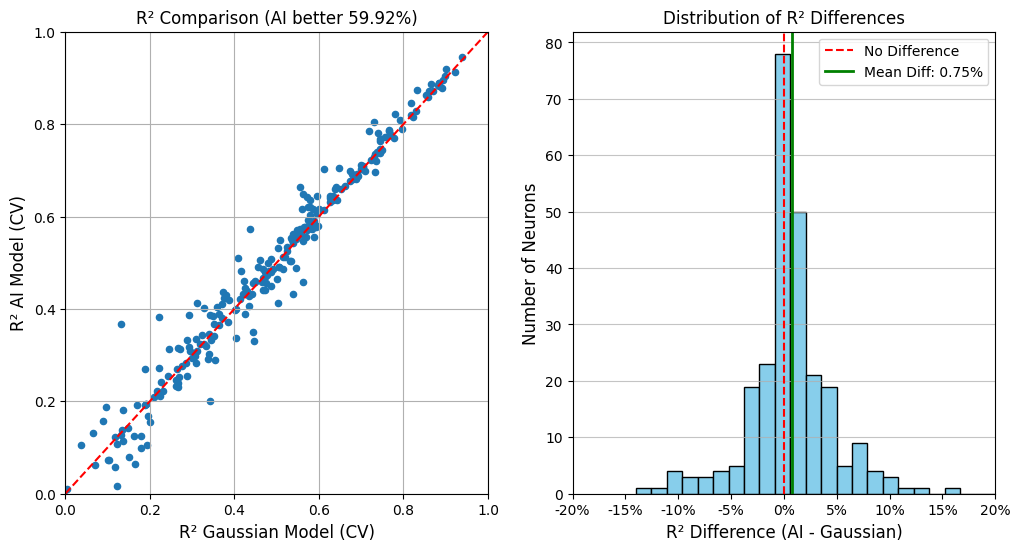

In [23]:
# plot scatter of r_squared for gaussian vs non-gaussian model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(r_squared_gauss, r_squared, alpha=1.0, color='tab:blue', s=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('R² Gaussian Model (CV)', fontsize=12)
plt.ylabel('R² AI Model (CV)', fontsize=12)
# calculate probability that AI model has higher R²
prob_ai_better = np.mean(r_squared > r_squared_gauss)
plt.title(f'R² Comparison (AI better {prob_ai_better:.2%})', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()

plt.subplot(1, 2, 2)
# show histogram of R² differences
r_squared_diff = r_squared - r_squared_gauss
plt.hist(r_squared_diff, bins=30, color='skyblue', edgecolor='black')
# dash line at zero
plt.axvline(0, color='red', linestyle='--', label='No Difference')
# line at mean difference
mean_diff = np.mean(r_squared_diff)
plt.axvline(mean_diff, color='green', linestyle='-', label=f'Mean Diff: {100 * mean_diff:.2f}%', linewidth=2)
plt.legend()
plt.xlabel('R² Difference (AI - Gaussian)', fontsize=12)
plt.xlim(-0.2, 0.2)
# label x ticks as percentages
plt.xticks(np.arange(-0.2, 0.25, 0.05), [f'{np.round(x*100).astype(int)}%' for x in np.arange(-0.2, 0.25, 0.05)])
plt.ylabel('Number of Neurons', fontsize=12)
plt.title('Distribution of R² Differences', fontsize=12)
plt.grid(axis='y', alpha=0.75) 
plt.show()

In [24]:
# compute mean r_squared and standard error of the mean
mean_r_squared = np.nanmean(r_squared)
sem_r_squared = np.nanstd(r_squared) / np.sqrt(np.sum(~np.isnan(r_squared)))
mean_r_squared_gauss = np.nanmean(r_squared_gauss)
sem_r_squared_gauss = np.nanstd(r_squared_gauss) / np.sqrt(np.sum(~np.isnan(r_squared_gauss)))
print(f"AI Model: Mean R² = {mean_r_squared:.4f} ± {sem_r_squared:.4f}")
print(f"Gaussian Model: Mean R² = {mean_r_squared_gauss:.4f} ± {sem_r_squared_gauss:.4f}")


AI Model: Mean R² = 0.4844 ± 0.0142
Gaussian Model: Mean R² = 0.4769 ± 0.0140


In [ ]:
# start, end = 0.0, 0.2
# n_loss_bins = 40
# plt.figure(figsize=(15, 5))
# plt.subplot(121)
# plt.hist(cv_loss, bins=np.linspace(start, end, n_loss_bins), alpha=0.5, label='ai model')
# plt.hist(cv_loss_gauss, bins=np.linspace(start, end, n_loss_bins), alpha=0.5, label='gaussian model')
# # add vertical line at mean
# # plt.axvline(x=np.median(cv_loss), color='blue', linestyle='--', label=f'ai median = {np.median(cv_loss):.4f}')
# plt.axvline(x=np.mean(cv_loss), color='blue', linestyle=':', label=f'ai mean = {np.mean(cv_loss):.4f}')
# # plt.axvline(x=np.median(cv_loss_gauss), color='orange', linestyle='--', label=f'gaussian median = {np.median(cv_loss_gauss):.4f}')
# plt.axvline(x=np.mean(cv_loss_gauss), color='orange', linestyle=':', label=f'gaussian mean = {np.mean(cv_loss_gauss):.4f}')
# plt.xlabel('Cross-validated Loss')
# plt.ylabel('Number of Cells')
# plt.title('Cross-validated Loss Distribution')
# plt.legend()
# plt.subplot(122)
# xmin, xmax = 0.5, 1.6
# loss_ratio = cv_loss / cv_loss_gauss
# finite_mask = np.isfinite(loss_ratio)
# plt.hist(loss_ratio[finite_mask], bins=np.linspace(xmin, xmax, 30), color='green', alpha=0.7)
# # plt.axvline(x=np.median(loss_ratio[finite_mask]), color='red', linestyle='--', label=f'median ratio = {np.median(loss_ratio[finite_mask]):.4f}')
# plt.axvline(x=np.mean(loss_ratio[finite_mask]), color='red', linestyle=':', label=f'mean ratio = {np.mean(loss_ratio[finite_mask]):.4f}')
# plt.axvline(x=1.0, color='black', linestyle=':', label='equal loss line')
# plt.xlabel('Loss Ratio (AI / Gaussian)')
# plt.ylabel('Number of Cells')
# plt.title('Cross-validated Loss Ratio Distribution')
# plt.legend()
# plt.show()

Plotting fits for cell 191


/tmp/ipykernel_73861/2803262370.py:158: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


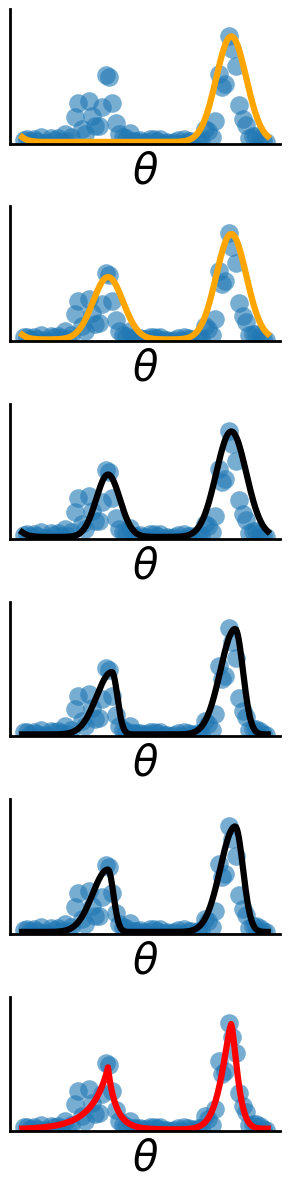

In [17]:
# define intermediate funcs
def neuron_model_3(theta, theta_pref, baseline, amp1, amp2, width1, width2):
    """
    Simplified two-peak neuron model with fixed Gaussian exponent of 2.0.
    """
    return neuron_model(
        theta,
        theta_pref_1=theta_pref,
        baseline=baseline,
        amplitude_1=amp1,
        width_ccw_1=width1,
        width_cw_1=width1,
        exponent_1=2.0,
        theta_pref_2=(theta_pref + np.pi) % (2 * np.pi),
        amplitude_2=amp2,
        width_ccw_2=width2,
        width_cw_2=width2,
        exponent_2=2.0
    )
def neuron_model_4(theta, theta_pref, baseline, amp1, width1_ccw, width1_cw, amp2, width2_ccw, width2_cw):
    """
    Simplified two-peak Gaussian neuron model.
    """
    return neuron_model(
        theta,
        theta_pref_1=theta_pref,
        baseline=baseline,
        amplitude_1=amp1,
        width_ccw_1=width1_ccw,
        width_cw_1=width1_cw,
        theta_pref_2=(theta_pref + np.pi) % (2 * np.pi),
        amplitude_2=amp2,
        width_ccw_2=width2_ccw,
        width_cw_2=width2_cw
    )
def neuron_model_5(theta, theta_pref_1, baseline, amp1, width1_ccw, width1_cw, theta_pref_2, amp2, width2_ccw, width2_cw):
    """
    Simplified two-peak Gaussian neuron model with fixed exponents of 2.0.
    """
    return neuron_model(
        theta,
        theta_pref_1=theta_pref_1,
        baseline=baseline,
        amplitude_1=amp1,
        width_ccw_1=width1_ccw,
        width_cw_1=width1_cw,
        theta_pref_2=theta_pref_2,
        amplitude_2=amp2,
        width_ccw_2=width2_ccw,
        width_cw_2=width2_cw
    )

# cell_no = np.random.randint(n_cells)
cell_no = 191
n_bins_plot = 72
bin_edges = np.linspace(0, 2 * np.pi, n_bins_plot + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
scale_factor = 3.0

print(f'Plotting fits for cell {cell_no}')
fig, axes = plt.subplots(6, 1, figsize=(1 * scale_factor, 4 * scale_factor), constrained_layout=True)
axes = axes.ravel()
neuron_models = [seed_programs.neuron_model_1_jax, seed_programs.neuron_model_2_jax, neuron_model_3, neuron_model_4, neuron_model_5, neuron_model]
model_names = ['S1', 'S2', 'A23', 'A27', 'C7', 'D15']
params_single_cell = np.array([params[cell_no]])[0]

# generate predictions for each model
pred = np.zeros((len(neuron_models), angles.shape[0]))
# params for model 1 are theta_pref1, baseline, amp1, width
params_model = params_single_cell[[0, 1, 2, 3]] 
params_model[3] = np.mean([params_single_cell[4], params_single_cell[5]]) * 0.5  # average width_ccw and width_cw for single width
pred[0] = neuron_models[0](angles, *params_model)

# params for model 2 are theta_pref1, baseline, amp1, amp2, width
params_model = params_single_cell[[0, 1, 2, 7, 3]]
params_model[4] = np.mean([params_single_cell[4], params_single_cell[5]]) * 0.5  # average width_ccw and width_cw for single width
pred[1] = neuron_models[1](angles, *params_model)

# params for model 3 are theta_pref1, baseline, amp1, amp2, width1, width2
params_model = params_single_cell[[0, 1, 2, 7, 3, 8]]
params_model[4] = np.mean([params_single_cell[4], params_single_cell[5]]) * 0.5  # average width_ccw and width_cw for peak 1
params_model[5] = np.mean([params_single_cell[8], params_single_cell[9]]) * 2 # average width_ccw and width_cw for peak 2
pred[2] = neuron_models[2](angles, *params_model)

# params for model 4 are theta_pref1, baseline, amp1, width1_ccw, width1_cw, amp2, width2_ccw, width2_cw
params_model = params_single_cell[[0, 1, 2, 3, 4, 7, 8, 9]]
# scale the widths up a bit
params_model[[3, 4]] *= 1.5  # use original widths scaled up
params_model[[6, 7]] *= 1.5  # use original widths scaled up
# scale left widths up more
params_model[[3, 6]] *= 1.25
# add small rightward shift to theta_pref1
params_model[0] = (params_model[0] + 0.1) % (2 * np.pi)
pred[3] = neuron_models[3](angles, *params_model)

# params for model 5 are theta_pref1, baseline, amp1, width1_ccw, width1_cw, theta_pref2, amp2, width2_ccw, width2_cw
params_model = params_single_cell[[0, 1, 2, 3, 4, 6, 7, 8, 9]]
# scale the widths up a bit
params_model[[3, 4]] *= 1.5  # use original widths scaled up
params_model[[7, 8]] *= 1.5  # use original widths scaled up
# scale left widths up more
params_model[[3, 7]] *= 1.25
# add small rightward shift to theta_pref1
params_model[0] = (params_model[0] + 0.1) % (2 * np.pi)
pred[4] = neuron_models[4](angles, *params_model)

# the final prediction is the AI model
pred[5] = neuron_models[5](angles, *params_single_cell)
colours = ['orange', 'orange', 'k', 'k', 'k', 'red']
for i in range(len(neuron_models)):
    ax = axes[i]

    # Binned means
    angle_masks = [(angles >= bin_edges[j]) & (angles <= bin_edges[j + 1]) for j in range(n_bins_plot)]
    binned_means = np.array([R_train[cell_no][angle_masks[j]].mean() for j in range(n_bins_plot)])

    # Plot test data
    ax.scatter(
        bin_centres, binned_means,
        label='Test Data', 
        color='tab:blue',
        s=60 * scale_factor, alpha=0.6, edgecolor='k', linewidth=0.0 * scale_factor
    )
    # Plot model prediction
    ax.plot(
        angles, pred[i],
        label=rf'{model_names[i]} Model',
        color=colours[i], linewidth=1.5 * scale_factor,
        linestyle='-'
    )

    # Axis labels and formatting
    row = i // 1
    # ax.set_xlabel('Angle (°)' if row == len(neuron_models) - 1 else '', fontsize=12)
    # ax.set_ylabel('Response', fontsize=12)
    ax.set_xticks([])
    # ax.set_xticklabels([f"{int(np.degrees(angle))}" for angle in np.linspace(0, 2 * np.pi, 9)], fontsize=10)
    ax.set_yticks([])
    # ax.tick_params(labelsize=10)
    ax.set_ylim(0, binned_means.max() * 1.25)
    # ax.grid(True, linestyle='--', alpha=0.6)
    # ax.legend(fontsize=10)
    # make the axis outlines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(r'$\theta$', fontsize=10 * scale_factor)

    # Title with key cell info
#     ax.set_title(
#         f'Model {model_names[i]} for Cell {cell_no}',
#         fontsize=11
#     )

# plt.suptitle("Neural Response Fits: AI Model vs Gaussian Model vs Test Data", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [162]:
# exponent1 = params[:, 5]
# exponent2 = params[:, 10]
# peaky = np.where((exponent1 < 1.5) | (exponent2 < 1.5))[0]
# peaky

In [163]:
# improved = np.where((r_squared - r_squared_gauss) > 0.05)[0]
# print(f'Number of improved cells: {len(improved)}')

Number of good cells: 66


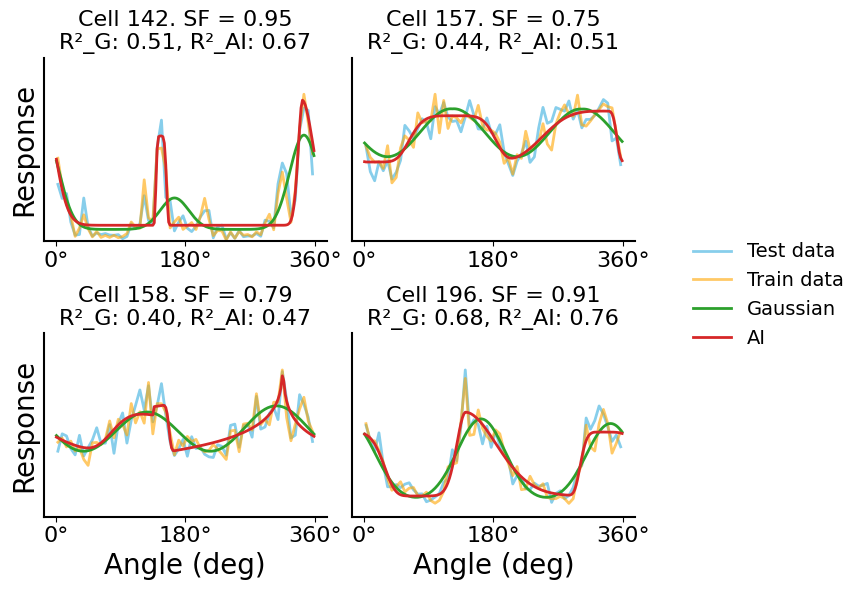

In [ ]:
# Example setup
# cells = [187, 624, 639, 741]
# cells = np.random.choice(n_cells, size=4, replace=False)
# cells = np.random.choice(peaky, size=4, replace=False)
# cells = np.random.choice(improved, size=4, replace=False)
# cells = [52, 321, 191, 431]
# cells = [70, 221, 440, 431]
# cells = np.random.choice(best_cells, size=4, replace=False)
good = (r_squared > 0.4) & (r_squared - r_squared_gauss > 0.02)
good_cells = np.where(good)[0]
print(f'Number of good cells: {len(good_cells)}')
cells = np.random.choice(good_cells, size=4, replace=False)
# order cells
cells = np.sort(cells)
# cells = [120, 220, 149, 88]

n_bins_plot = 60
bin_edges = np.linspace(0, 2 * np.pi, n_bins_plot + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
scale_factor = 2.0
fig, axes = plt.subplots(2, 2,
                         figsize=(4 * scale_factor, 3 * scale_factor))
axes = axes.ravel()

for i, cell_no in enumerate(cells):
    ax = axes[i]

    pred       = neuron_model(angles, *params[cell_no])
    pred_gauss = neuron_model_gauss(angles, *params_gauss[cell_no])

    angle_masks = [(angles >= bin_edges[j]) & (angles < bin_edges[j + 1]) for j in range(n_bins_plot)]
    binned_means_test  = np.array([R_test[cell_no][angle_masks[j]].mean()  if angle_masks[j].any() else np.nan
                                   for j in range(n_bins_plot)])
    binned_means_train = np.array([R_train[cell_no][angle_masks[j]].mean() if angle_masks[j].any() else np.nan
                                   for j in range(n_bins_plot)])

    # Raw scatter (very faint)
    # ax.scatter(angles, R_test[cell_no], color='tab:blue', s=10, alpha=0.5, linewidths=0.5, edgecolor='k', label='Test data')

    # Binned means
    ax.plot(bin_centres, binned_means_test,  color='skyblue', linewidth=2, label='Test data')
    ax.plot(bin_centres, binned_means_train, color='orange',  linewidth=2, label='Train data', alpha=0.6)

    # Model predictions
    ax.plot(angles, pred_gauss, color='tab:green', linewidth=2, label='Gaussian')
    ax.plot(angles, pred,       color='tab:red',   linewidth=2, label='AI')

    n_ticks = 3
    row, col = divmod(i, 2)
    ax.set_xlabel('Angle (deg)' if row == 1 else '', fontsize=10 * scale_factor)
    ax.set_ylabel('Response'    if col == 0 else '', fontsize=10 * scale_factor)
    ax.set_xticks(np.linspace(0, 2 * np.pi, n_ticks))
    ax.set_xticklabels([f"{int(np.degrees(a))}°" for a in np.linspace(0, 2 * np.pi, n_ticks)],
                       fontsize=8 * scale_factor)
    ax.set_yticks([])
    ax.tick_params(labelsize=8 * scale_factor)
    model_max = max(pred.max(), pred_gauss.max())
    ax.set_ylim(0, max(np.nanmax(binned_means_test), np.nanmax(binned_means_train), model_max) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)

    ax.set_title(
        f'Cell {cell_no}. SF = {signal_fractions[cell_no]:.2f}\n'
        f'R²_G: {r_squared_gauss[cell_no]:.2f}, R²_AI: {r_squared[cell_no]:.2f}',
        fontsize=8 * scale_factor
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='center left', bbox_to_anchor=(0.85, 0.5),
           fontsize=7 * scale_factor, frameon=False)
fig.tight_layout()
fig.subplots_adjust(right=0.80)
plt.show()

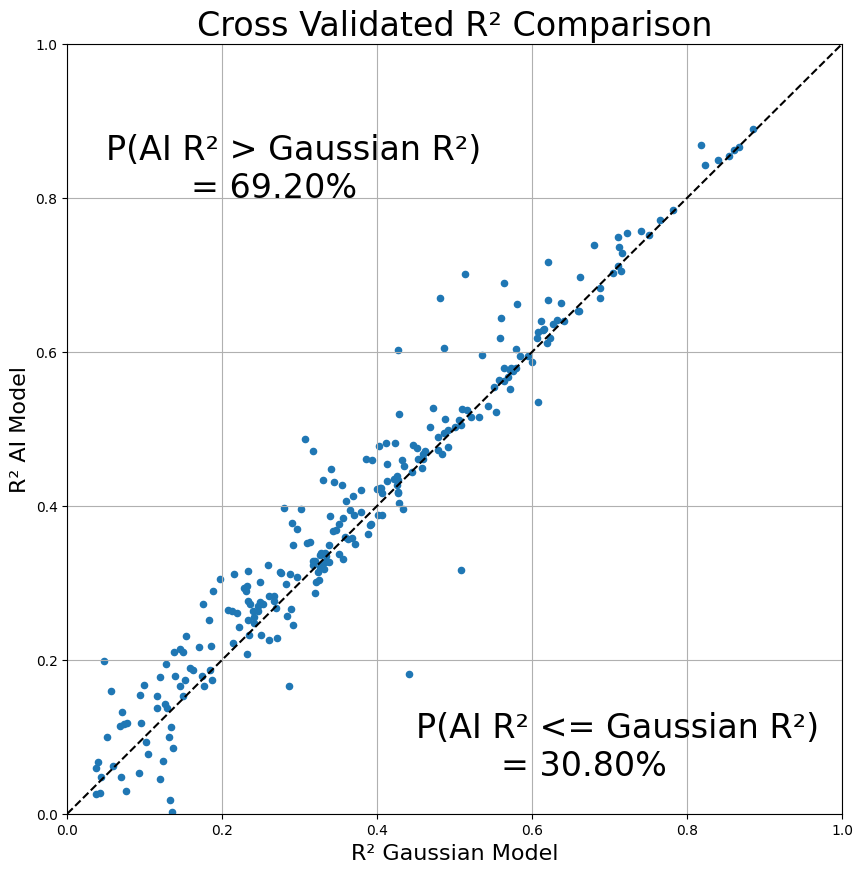

In [250]:
x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0
plt.figure(figsize=(10, 10))
plt.scatter(r_squared_gauss, r_squared, alpha=1, color='tab:blue', s=20)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('R² Gaussian Model', fontsize=16)
plt.ylabel('R² AI Model', fontsize=16)
plt.title('Cross Validated R² Comparison', fontsize=24)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True)
# in top left corner, add text showing number of points above y = x line
n_above = np.sum(r_squared > r_squared_gauss)
# plt.text(x_min*1.1, y_max*0.9, f'P(AI R² > Gaussian R²) \n        = {n_above / len(r_squared):.2%}', fontsize=24, color='k')
plt.text(0.05, 0.8, f'P(AI R² > Gaussian R²) \n        = {prob_ai_better:.2%}', fontsize=24, color='k')
# in bottom right corner, add text showing number of points below y = x line
n_below = np.sum(r_squared <= r_squared_gauss)
# plt.text(x_max * 0.7, y_min * 1.1, f'P(AI R² <= Gaussian R²) \n        = {n_below / len(r_squared):.2%}', fontsize=24, color='k')
plt.text(0.45, 0.05, f'P(AI R² <= Gaussian R²) \n        = {1 - prob_ai_better:.2%}', fontsize=24, color='k')
plt.show()

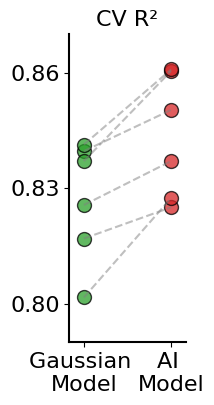

In [593]:
x_min, x_max = 0.75, 2.25
x_gauss = np.ones(6) * x_min
y_gauss = np.array([0.8256, 0.8396, 0.8169, 0.8370, 0.8016, 0.8413])
x_ai = np.ones(6) * x_max
y_ai = np.array([0.8370, 0.8503, 0.8250, 0.8604, 0.8274, 0.8608])
y_gauss_mean = y_gauss.mean()
y_ai_mean = y_ai.mean()
scale_factor = 2.0
plt.figure(figsize=(0.75 * scale_factor, 2 * scale_factor))
plt.scatter(x_gauss, y_gauss, s=50 * scale_factor, alpha=0.75, c='tab:green', edgecolors='k', label='Gauss')
# plt.scatter([1], [y_gauss_mean], s=30 * scale_factor, c='tab:green', marker='^', edgecolors='k', alpha=0.9,
#             label=f'Gauss Mean: {y_gauss_mean:.2f}', zorder=5)
# plt.axhline(y=y_gauss_mean, color='tab:green', linestyle='--', alpha=0.8)
plt.scatter(x_ai, y_ai, s=50 * scale_factor, alpha=0.75, c='tab:red', edgecolors='k', label='AI')
# plt.scatter([2], [y_ai_mean], s=30 * scale_factor, c='tab:red', marker='^', edgecolors='k', alpha=0.9,
#             label=f'AI Mean: {y_ai_mean:.2f}', zorder=5)
# plt.legend(fontsize=8 * scale_factor, loc='upper left', frameon=False)
plt.xticks([x_min, x_max], ['Gaussian \nModel', 'AI \nModel'], fontsize=8 * scale_factor)
# add grey lines joining pairs
for i in range(len(y_gauss)):
    plt.plot([x_gauss[i], x_ai[i]], [y_gauss[i], y_ai[i]], color='gray', linestyle='--', alpha=0.5)
# plt.plot([1, 2], [y_gauss_mean, y_ai_mean], color='black', linestyle='--', alpha=0.8)
# plt.ylabel('Cross-validated R²', 
#            fontsize=8 * scale_factor)
plt.xlim(0.5, 2.5)
plt.ylim(0.79, 0.87)
plt.yticks([0.80, 0.83, 0.86], 
           fontsize=8 * scale_factor)
plt.title('CV R²', fontsize=8 * scale_factor)
# turn off top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# make bottom and left spines thicker
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

plt.savefig('/home/reilly/ai_scientist_project/figures/r2_comparison.svg', format='svg', dpi=300, bbox_inches='tight')

(0.5, 2.5)

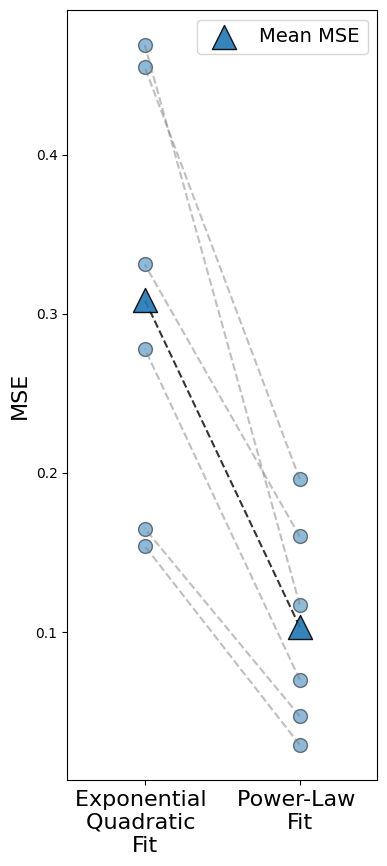

In [102]:
x_loglog = np.ones(6) * 2
y_loglog = np.array([0.117, 0.160, 0.196, 0.070, 0.029, 0.047])
x_loglinear = np.ones(6) * 1
y_loglinear = np.array([0.469, 0.331, 0.455, 0.278, 0.154, 0.165])
y_loglog_mean = y_loglog.mean()
y_loglinear_mean = y_loglinear.mean()
plt.figure(figsize=(4, 10))
plt.scatter(x_loglog, y_loglog, s=100, alpha=0.5, c='tab:blue', edgecolors='k')
plt.scatter([2], [y_loglog_mean], s=300, c='tab:blue', marker='^', edgecolors='k', alpha=0.9,
            label='Mean MSE', zorder=5)
# plt.axhline(y=y_loglog_mean, color='tab:blue', linestyle='--', alpha=0.8)
plt.scatter(x_loglinear, y_loglinear, s=100, alpha=0.5, c='tab:blue', edgecolors='k')
plt.scatter([1], [y_loglinear_mean], s=300, c='tab:blue', marker='^', edgecolors='k', alpha=0.9,zorder=5)
# plt.axhline(y=y_loglinear_mean, color='tab:blue', linestyle='--', alpha=0.8)
plt.xticks([2, 1], ['Power-Law \nFit', 'Exponential \nQuadratic \nFit'], fontsize=16)
plt.legend(fontsize=14, loc='upper right')
# add grey lines joining pairs
for i in range(len(y_loglog)):
    plt.plot([x_loglog[i], x_loglinear[i]], [y_loglog[i], y_loglinear[i]], color='gray', linestyle='--', alpha=0.5)
plt.plot([2, 1], [y_loglog_mean, y_loglinear_mean], color='black', linestyle='--', alpha=0.8)
plt.ylabel('MSE', fontsize=16)
plt.xlim(0.5, 2.5)
# plt.ylim(0, 0.6)


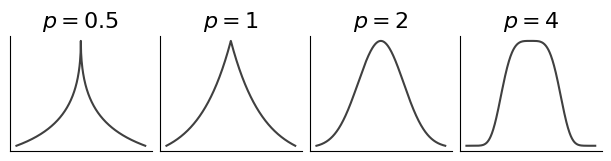

In [587]:
# plot exp(-|x|^p) for p=0.5, 1, 2, 4
x = np.linspace(-2, 2, 501)
scale_factor = 2.0
fig, ax = plt.subplots(1, 4, figsize=(3 * scale_factor, 0.75 * scale_factor), constrained_layout=True)
p_values = [0.5, 1, 2, 4]
for i, p in enumerate(p_values):
    y = np.exp(-np.abs(x) ** p)
    ax[i].plot(x, y, color='k', linewidth=0.75 * scale_factor, alpha=0.75, linestyle='-')
    ax[i].set_title(rf'$p={p}$', fontsize=8 * scale_factor)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    # turn off top and right spines
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    # make bottom and left spines thicker
    # ax[i].spines['bottom'].set_linewidth(1.5)
    # ax[i].spines['left'].set_linewidth(1.5)
# plt.suptitle('Generalized Gaussian Functions', fontsize=20)
plt.show()


In [550]:
# ── fit tuning curves per 330ms time bin ──────────────────────────────────
TS_330_PATH    = '/home/reilly/datasets/hayley_data/spike_timeseries_bs330ms_0p0-1p0.npy'
timeseries_330 = np.load(TS_330_PATH)   # (564, 360, 6, 3)

angles_ts = np.deg2rad(np.arange(360))                            # (360,) radians
x_data_ts = np.repeat(angles_ts[None, :], n_cells, axis=0)        # (n_cells, 360)

bin_labels = ['0–330 ms', '330–660 ms', '660–990 ms']
params_ts  = []
R_train_ts = []
R_test_ts  = []

for t in range(3):
    counts_t = timeseries_330[global_cell_indices, :, :, t]   # (n_cells, 360, 6)
    counts_t = np.transpose(counts_t, (2, 0, 1))              # (6, n_cells, 360)

    Rt_train = np.nanmean(counts_t[::2],  axis=0)             # (n_cells, 360)  odd repeats
    Rt_test  = np.nanmean(counts_t[1::2], axis=0)             # (n_cells, 360)  even repeats

    params_init_t = np.array([parameter_estimator(angles_ts, Rt_train[i]) for i in range(n_cells)])
    p_t, l_t = train_model(neuron_model, params_init_t, Rt_train, x_data_ts,
                            learning_rate=1e-3, num_steps=10_000)

    params_ts.append(p_t)
    R_train_ts.append(Rt_train)
    R_test_ts.append(Rt_test)
    print(f'{bin_labels[t]}: loss = {l_t:.4f}')

params_ts  = np.array(params_ts)    # (3, n_cells, n_params)
R_train_ts = np.array(R_train_ts)   # (3, n_cells, 360)
R_test_ts  = np.array(R_test_ts)    # (3, n_cells, 360)


Step   200 | loss 2.2110 | NaN cells: 0
Step   400 | loss 2.0824 | NaN cells: 0
Step   600 | loss 2.0301 | NaN cells: 0
Step   800 | loss 1.9983 | NaN cells: 0
Step  1000 | loss 1.9795 | NaN cells: 0
Step  1200 | loss 1.9693 | NaN cells: 0
Step  1400 | loss 1.9614 | NaN cells: 0
Step  1600 | loss 1.9539 | NaN cells: 0
Step  1800 | loss 1.9486 | NaN cells: 0
Step  2000 | loss 1.9447 | NaN cells: 0
Step  2200 | loss 1.9415 | NaN cells: 0
Step  2400 | loss 1.9392 | NaN cells: 0
Step  2600 | loss 1.9321 | NaN cells: 0
Step  2800 | loss 1.9291 | NaN cells: 0
Step  3000 | loss 1.9254 | NaN cells: 0
Step  3200 | loss 1.9220 | NaN cells: 0
Step  3400 | loss 1.9191 | NaN cells: 0
Step  3600 | loss 1.9165 | NaN cells: 0
Step  3800 | loss 1.9145 | NaN cells: 0
Step  4000 | loss 1.9146 | NaN cells: 0
Step  4200 | loss 1.9136 | NaN cells: 0
Step  4400 | loss 1.9121 | NaN cells: 0
Step  4600 | loss 1.9106 | NaN cells: 0
Step  4800 | loss 1.9091 | NaN cells: 0
Step  5000 | loss 1.9085 | NaN cells: 0


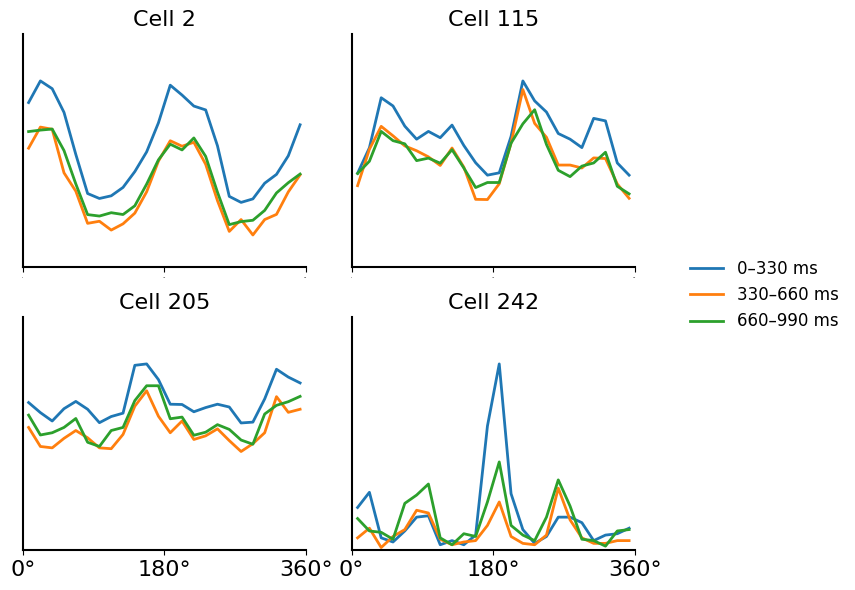

In [956]:
# ── 2×2 superimposed binned means per time bin ────────────────────────────
good = (r_squared > 0.3)
good_cells_ts = np.where(good)[0]
cells_ts = np.sort(np.random.choice(good_cells_ts, size=4, replace=False))

n_bins_plot  = 24
bin_edges_plot   = np.linspace(0, 2 * np.pi, n_bins_plot + 1)
bin_centres_plot = (bin_edges_plot[:-1] + bin_edges_plot[1:]) / 2
angle_masks = [(angles_ts >= bin_edges_plot[j]) & (angles_ts < bin_edges_plot[j + 1])
               for j in range(n_bins_plot)]

bin_colors = ['tab:blue', 'tab:orange', 'tab:green']
scale_factor = 2.0
fig, axes = plt.subplots(2, 2, figsize=(4 * scale_factor, 3 * scale_factor))
axes = axes.ravel()

for i, cell_no in enumerate(cells_ts):
    ax = axes[i]
    all_vals = []
    for t in range(3):
        R_all = (R_train_ts[t, cell_no] + R_test_ts[t, cell_no]) / 2
        binned = np.array([
            R_all[angle_masks[j]].mean() if angle_masks[j].any() else np.nan
            for j in range(n_bins_plot)
        ])
        ax.plot(bin_centres_plot, binned, color=bin_colors[t], linewidth=2,
                label=bin_labels[t] if i == 0 else '_')
        all_vals.append(np.nanmax(binned))

    row, col = divmod(i, 2)
    ax.set_xticks(np.linspace(0, 2 * np.pi, 3))
    ax.set_xticklabels(
        [f'{int(np.degrees(a))}°' for a in np.linspace(0, 2 * np.pi, 3)],
        fontsize=8 * scale_factor if row == 1 else 0
    )
    ax.set_yticks([])
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(0, max(all_vals) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.set_title(f'Cell {cell_no}', fontsize=8 * scale_factor)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.85, 0.5),
           fontsize=6 * scale_factor, frameon=False)
fig.tight_layout()
fig.subplots_adjust(right=0.80)
plt.show()


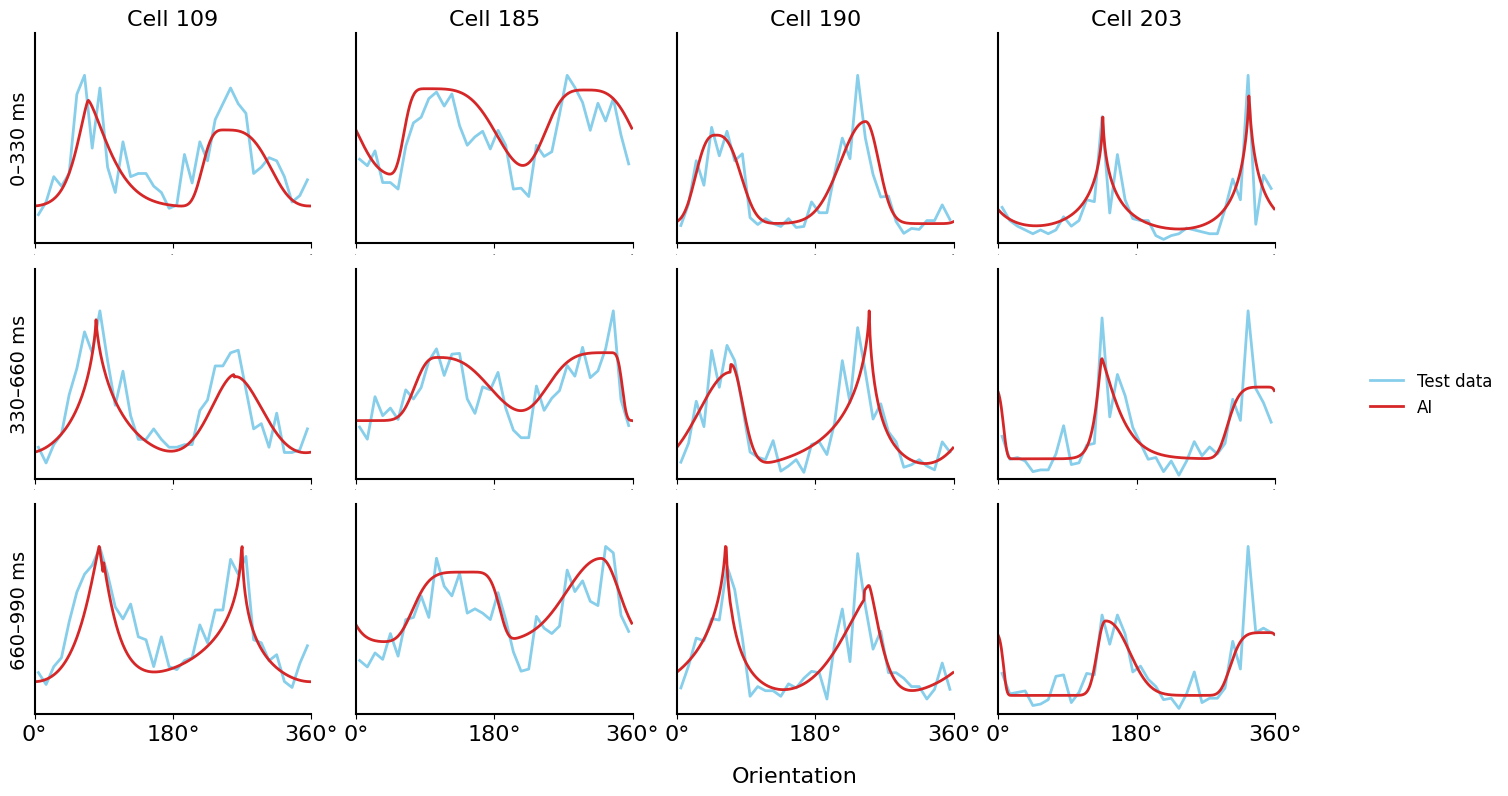

In [819]:
# ── time-binned tuning curves: 4 cells × 3 time bins ─────────────────────
good = r_squared > 0.4
good_cells_ts = np.where(good)[0]
cells_ts = np.sort(np.random.choice(good_cells_ts, size=4, replace=False))

n_bins_plot = 36
bin_edges_plot  = np.linspace(0, 2 * np.pi, n_bins_plot + 1)
bin_centres_plot = (bin_edges_plot[:-1] + bin_edges_plot[1:]) / 2
angle_masks = [(angles_ts >= bin_edges_plot[j]) & (angles_ts < bin_edges_plot[j + 1])
               for j in range(n_bins_plot)]

scale_factor = 2.0
fig, axes = plt.subplots(3, 4, figsize=(8 * scale_factor, 4 * scale_factor))

for row, t in enumerate(range(3)):
    for col, cell_no in enumerate(cells_ts):
        ax = axes[row, col]

        binned_means_test = np.array([
            R_test_ts[t, cell_no][angle_masks[j]].mean() if angle_masks[j].any() else np.nan
            for j in range(n_bins_plot)
        ])
        pred = neuron_model(angles_ts, *params_ts[t, cell_no])

        ax.plot(bin_centres_plot, binned_means_test, color='skyblue', linewidth=2, label='Test data')
        ax.plot(angles_ts,        pred,              color='tab:red',  linewidth=2, label='AI')

        ax.set_xticks(np.linspace(0, 2 * np.pi, 3))
        ax.set_xticklabels(
            [f'{int(np.degrees(a))}°' for a in np.linspace(0, 2 * np.pi, 3)],
            fontsize=8 * scale_factor if row == 2 else 0
        )
        ax.set_yticks([])
        ax.set_xlim(0, 2 * np.pi)
        ax.set_ylim(0, max(np.nanmax(binned_means_test), pred.max()) * 1.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['left'].set_linewidth(1.5)

        if row == 0:
            ax.set_title(f'Cell {cell_no}', fontsize=8 * scale_factor)
        if col == 0:
            ax.set_ylabel(bin_labels[t], fontsize=7 * scale_factor)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.85, 0.5),
           fontsize=6 * scale_factor, frameon=False)
fig.supxlabel('Orientation', fontsize=8 * scale_factor)
fig.tight_layout()
fig.subplots_adjust(right=0.80)
plt.show()


/tmp/ipykernel_2427899/2674977399.py:34: RuntimeWarning: divide by zero encountered in divide
  R_norm     = (R_test - baseline) / amplitude
/tmp/ipykernel_2427899/2674977399.py:34: RuntimeWarning: invalid value encountered in divide
  R_norm     = (R_test - baseline) / amplitude


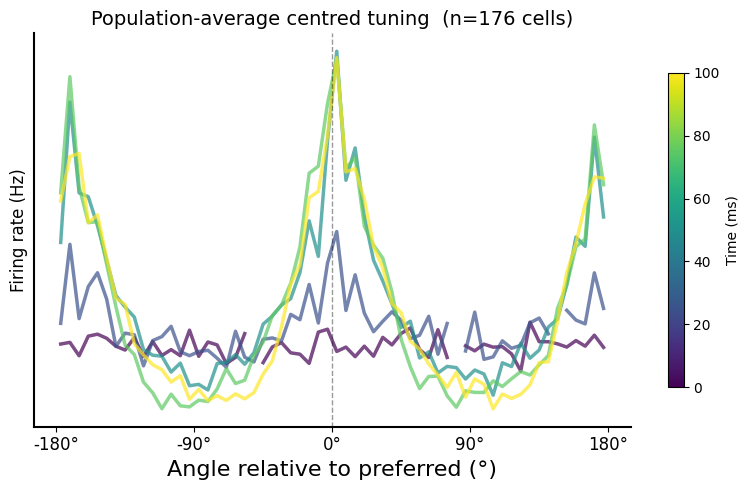

In [1023]:
# ── population-average centred tuning curves — one line per time bin ──────
ms_bin = 20
TS_PATH_FINE   = f'/home/reilly/datasets/hayley_data/spike_timeseries_bs{ms_bin}ms_0p0-1p0.npy'
BIN_EDGES_FINE = f'/home/reilly/datasets/hayley_data/spike_timeseries_bs{ms_bin}ms_0p0-1p0_bin_edges.npy'

ts_fine = np.load(TS_PATH_FINE)    # (564, 360, 6, n_t)
n_bins_crop = 5
ts_fine = ts_fine[:, :, :, :n_bins_crop]  # keep only first few bins to avoid long wait times
be_fine = np.load(BIN_EDGES_FINE)  # (n_t+1,) seconds
be_ms   = be_fine * n_bins_crop * ms_bin
n_tbins = ts_fine.shape[-1]

r_thresh = 0.3
good     = (r_squared > r_thresh)
good_idx = np.where(good)[0]
n_ori    = 360
centre   = n_ori // 2

n_bins_plot = 60
bin_edges_c = np.linspace(0, n_ori, n_bins_plot + 1)
x_deg       = np.array([(int(bin_edges_c[j]) + int(bin_edges_c[j+1])) / 2 - centre
                         for j in range(n_bins_plot)])

centred_curves = np.full((n_tbins, len(good_idx), n_ori), np.nan)

for t in range(n_tbins):
    for gi, cell_no in enumerate(good_idx):
        global_idx = global_cell_indices[cell_no]
        R_train    = ts_fine[global_idx, :, ::2, t].mean(axis=-1)   # mean over even repeats → (360,)
        R_test     = ts_fine[global_idx, :, 1::2, t].mean(axis=-1)   # mean over odd repeats → (360,)
        pref_idx   = int(np.argmax(R_train))
        baseline   = np.min(R_train)
        amplitude  = np.max(R_train) - baseline
        R_norm     = (R_test - baseline) / amplitude
        centred_curves[t, gi] = np.roll(R_norm, centre - pref_idx)

mean_curves = np.nanmean(centred_curves, axis=1)   # (n_tbins, 360)

cmap   = plt.cm.viridis
colors = [cmap(t / (n_tbins - 1)) for t in range(n_tbins)]

scale_factor = 2.0
fig, ax = plt.subplots(figsize=(4 * scale_factor, 2.5 * scale_factor))

for t in range(n_tbins):
    binned = np.array([mean_curves[t, int(bin_edges_c[j]):int(bin_edges_c[j+1])].mean()
                       for j in range(n_bins_plot)])
    ax.plot(x_deg, binned, color=colors[t], linewidth=2.5, alpha=0.7,
            label=f'{be_ms[t]:.0f}–{be_ms[t+1]:.0f} ms')

ax.axvline(0, color='k', linewidth=1, linestyle='--', alpha=0.4)
ax.set_xlabel('Angle relative to preferred (°)', fontsize=8 * scale_factor)
# ax.set_ylabel('(Rate − baseline) / amplitude', fontsize=6 * scale_factor)
ax.set_ylabel('Firing rate (Hz)', fontsize=6 * scale_factor)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_xticklabels(['-180°', '-90°', '0°', '90°', '180°'], fontsize=6 * scale_factor)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.set_title(f'Population-average centred tuning  (n={len(good_idx)} cells)', fontsize=7 * scale_factor)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=be_ms[0], vmax=be_ms[-1]))
plt.colorbar(sm, ax=ax, label='Time (ms)', shrink=0.8)
plt.tight_layout()
plt.show()
